In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

sc.set_figure_params(figsize=(5, 5))

In [2]:
adata = sc.read_h5ad("./heemskerk_data/adata_timeseries_old_48-96h.h5ad")
meta = pd.read_csv("./heemskerk_data/MP_old_48-96h_new_D6-10_meta.csv", index_col=0)
adata.obs = adata.obs.merge(meta, how="left", left_index=True, right_index=True)
adata.obsm["X_umap"] = np.array(
    adata.obs.loc[:, ["umap_old_48-96h_x", "umap_old_48-96h_y"]]
)

In [3]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

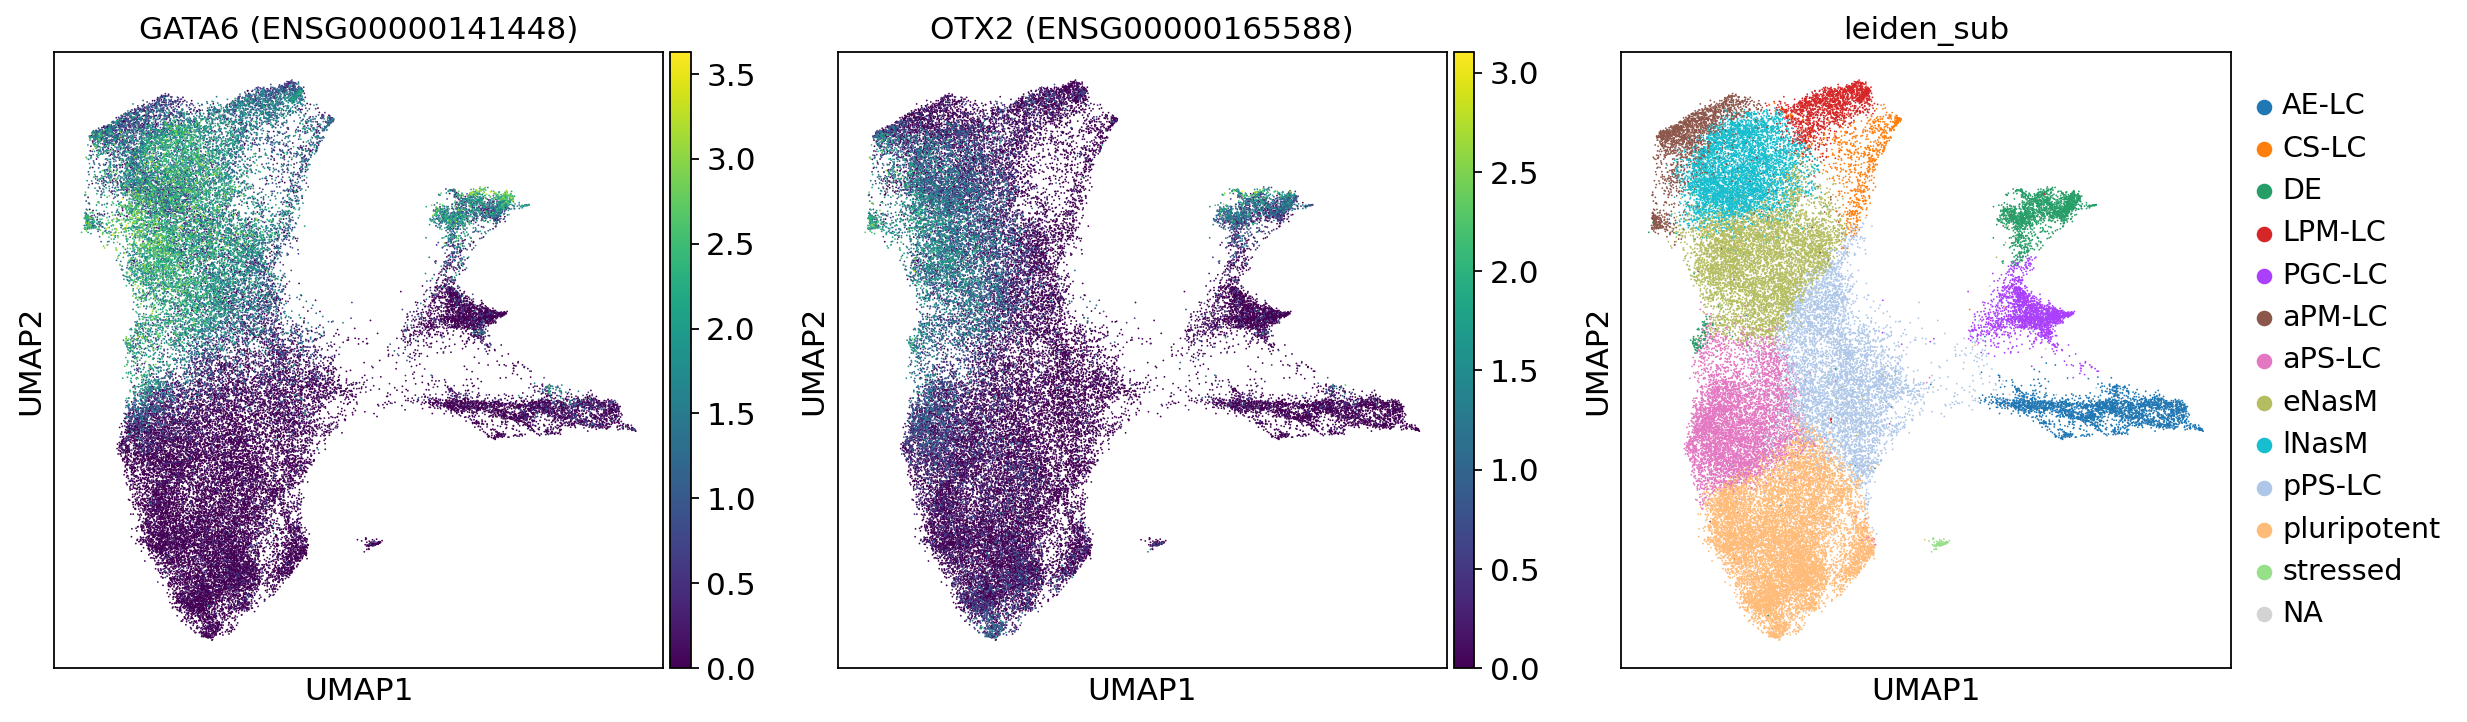

In [4]:
sc.pl.umap(
    adata,
    color=list(adata.var_names[adata.var_names.str.contains("OTX2|GATA6")])
    + ["leiden_sub"],
)

In [5]:
adata_48h = adata[adata.obs["sample_labels_x"].str.contains("48h-1")].copy()

In [6]:
sc.pp.highly_variable_genes(
    adata_48h,
    n_top_genes=2000,
    flavor="seurat_v3",
    subset=True,
    layer="counts",
)
sc.pp.pca(adata_48h)

In [24]:
import phate

phate_op = phate.PHATE(n_components=3, knn=15)
adata_48h.obsm["X_phate"] = phate_op.fit_transform(adata_48h.obsm["X_pca"])

Calculating PHATE...
  Running PHATE on 5927 observations and 50 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.11 seconds.
    Calculating affinities...
    Calculated affinities in 0.08 seconds.
  Calculated graph and diffusion operator in 0.19 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.46 seconds.
    Calculating KMeans...
    Calculated KMeans in 3.23 seconds.
  Calculated landmark operator in 3.70 seconds.
  Calculating optimal t...
    Automatically selected t = 21
  Calculated optimal t in 0.95 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.30 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.14 seconds.
Calculated PHATE in 7.50 seconds.


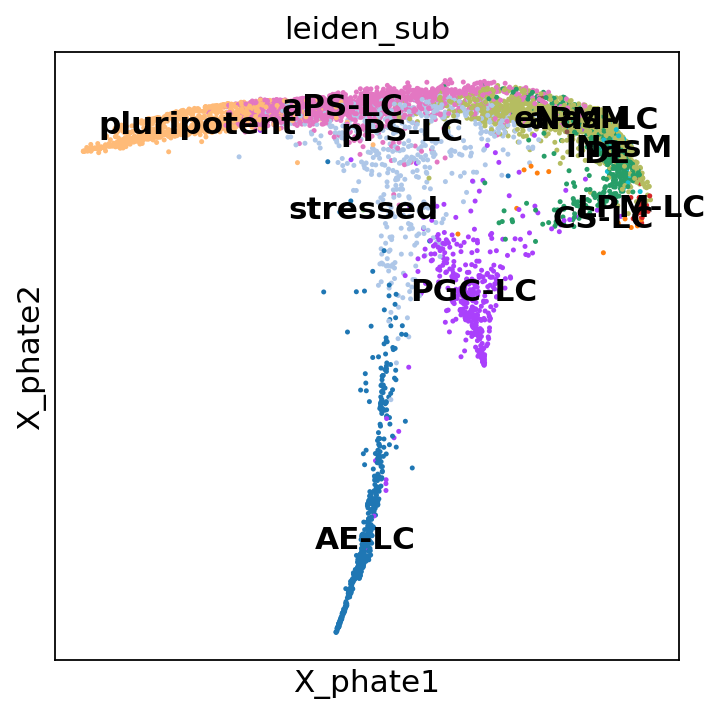

In [25]:
sc.pl.embedding(
    adata_48h,
    "X_phate",
    color="leiden_sub",
    legend_loc="on data",
)

In [54]:
import elpigraph

coords = adata_48h.obsm["X_phate"].copy()
pg_tree = elpigraph.computeElasticPrincipalTree(
    coords,
    NumNodes=40,
    Do_PCA=False,
    CenterData=False,
)[0]

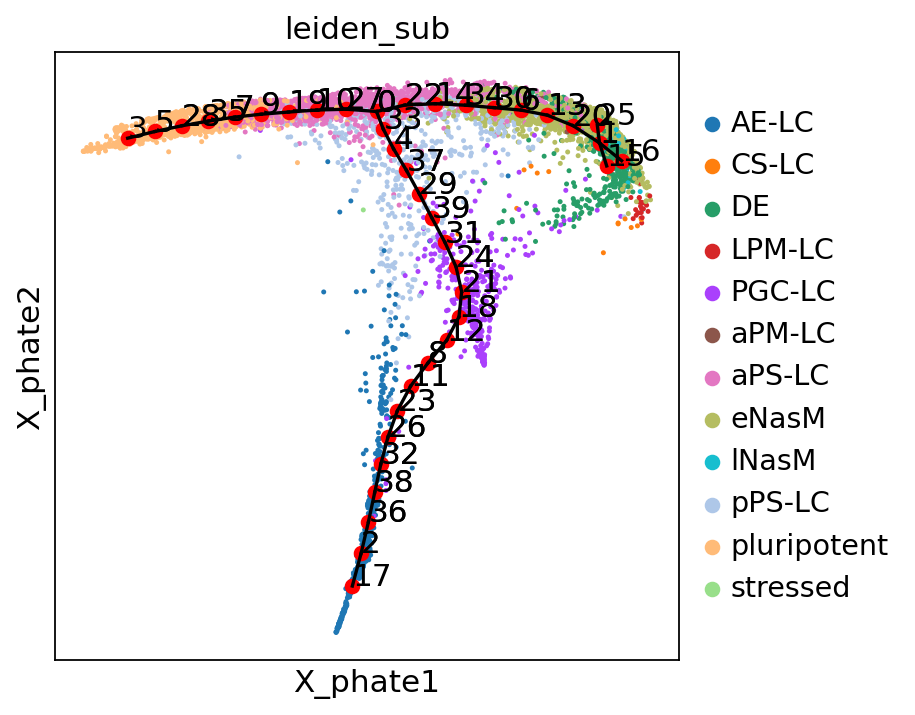

In [ ]:
ax = sc.pl.embedding(
    adata_48h,
    "X_phate",
    color="leiden_sub",
    # legend_loc="on data",
    show=False,
)
ax.scatter(pg_tree["NodePositions"][:, 0], pg_tree["NodePositions"][:, 1], c="red")
edges = pg_tree["Edges"][0]
for edge in edges:
    ax.plot(
        pg_tree["NodePositions"][edge, 0],
        pg_tree["NodePositions"][edge, 1],
        c="black",
    )
    ax.text(
        pg_tree["NodePositions"][edge[0], 0],
        pg_tree["NodePositions"][edge[0], 1],
        str(edge[0]),
        c="black",
    )
    ax.text(
        pg_tree["NodePositions"][edge[1], 0],
        pg_tree["NodePositions"][edge[1], 1],
        str(edge[1]),
        c="black",
    )


In [58]:
new_pg = elpigraph._graph_editing.addPath(coords, pg_tree, 24, 15, refit_graph=True)
new_pg = elpigraph._graph_editing.addPath(coords, new_pg, 37, 26, refit_graph=True)

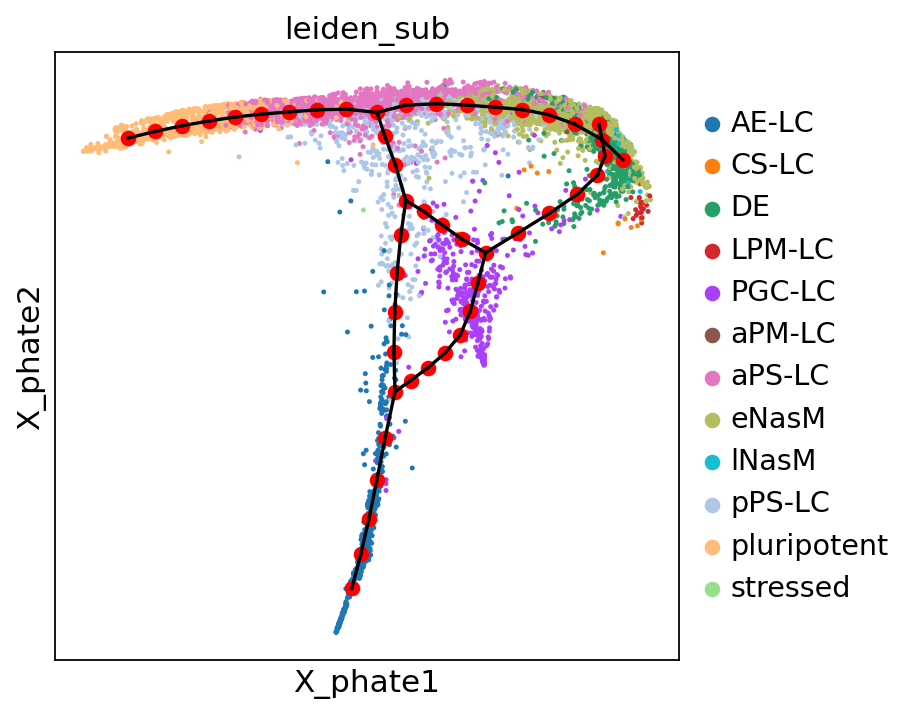

In [ ]:
ax = sc.pl.embedding(
    adata_48h,
    "X_phate",
    color="leiden_sub",
    show=False,
)
ax.scatter(new_pg["NodePositions"][:, 0], new_pg["NodePositions"][:, 1], c="red")
edges = new_pg["Edges"][0]
for edge in edges:
    ax.plot(
        new_pg["NodePositions"][edge, 0],
        new_pg["NodePositions"][edge, 1],
        c="black",
    )